# Credit Spread EDA
**Data**: `Agg_Data.xlsx` — 303 IG bonds, Mar 2024 – Feb 2026

### Analyses
1. Spread Regime Detection via Rolling Volatility & Level
2. Rating Cohort Spread Divergence Over Time
3. Duration-Adjusted Spread by Sector (BICS Level 1)
4. Spread Correlation Clustering
5. Spread Distribution by Sector (BICS Level 1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

# ── Load data ──────────────────────────────────────────────────────────────
spread_raw = pd.read_excel('Agg_Data.xlsx', sheet_name='Agg_Dirty_Spread')
fixed      = pd.read_excel('Agg_Data.xlsx', sheet_name='Agg_Fixed_Field')

spread_raw['Date'] = pd.to_datetime(spread_raw['Date'])
spread_raw = spread_raw.set_index('Date').sort_index()

# ── Align bond universe ────────────────────────────────────────────────────
fixed = fixed.set_index('CUSIP')
common = spread_raw.columns.intersection(fixed.index)
spreads = spread_raw[common]          # 499 × 303
meta    = fixed.loc[common]           # 303 × 10

print(f"Bonds: {spreads.shape[1]}  |  Trading days: {spreads.shape[0]}")
print(f"Date range: {spreads.index[0].date()} → {spreads.index[-1].date()}")

Bonds: 303  |  Trading days: 499
Date range: 2024-03-01 → 2026-02-26


---
## 1 · Spread Regime Detection — Rolling Level & Volatility

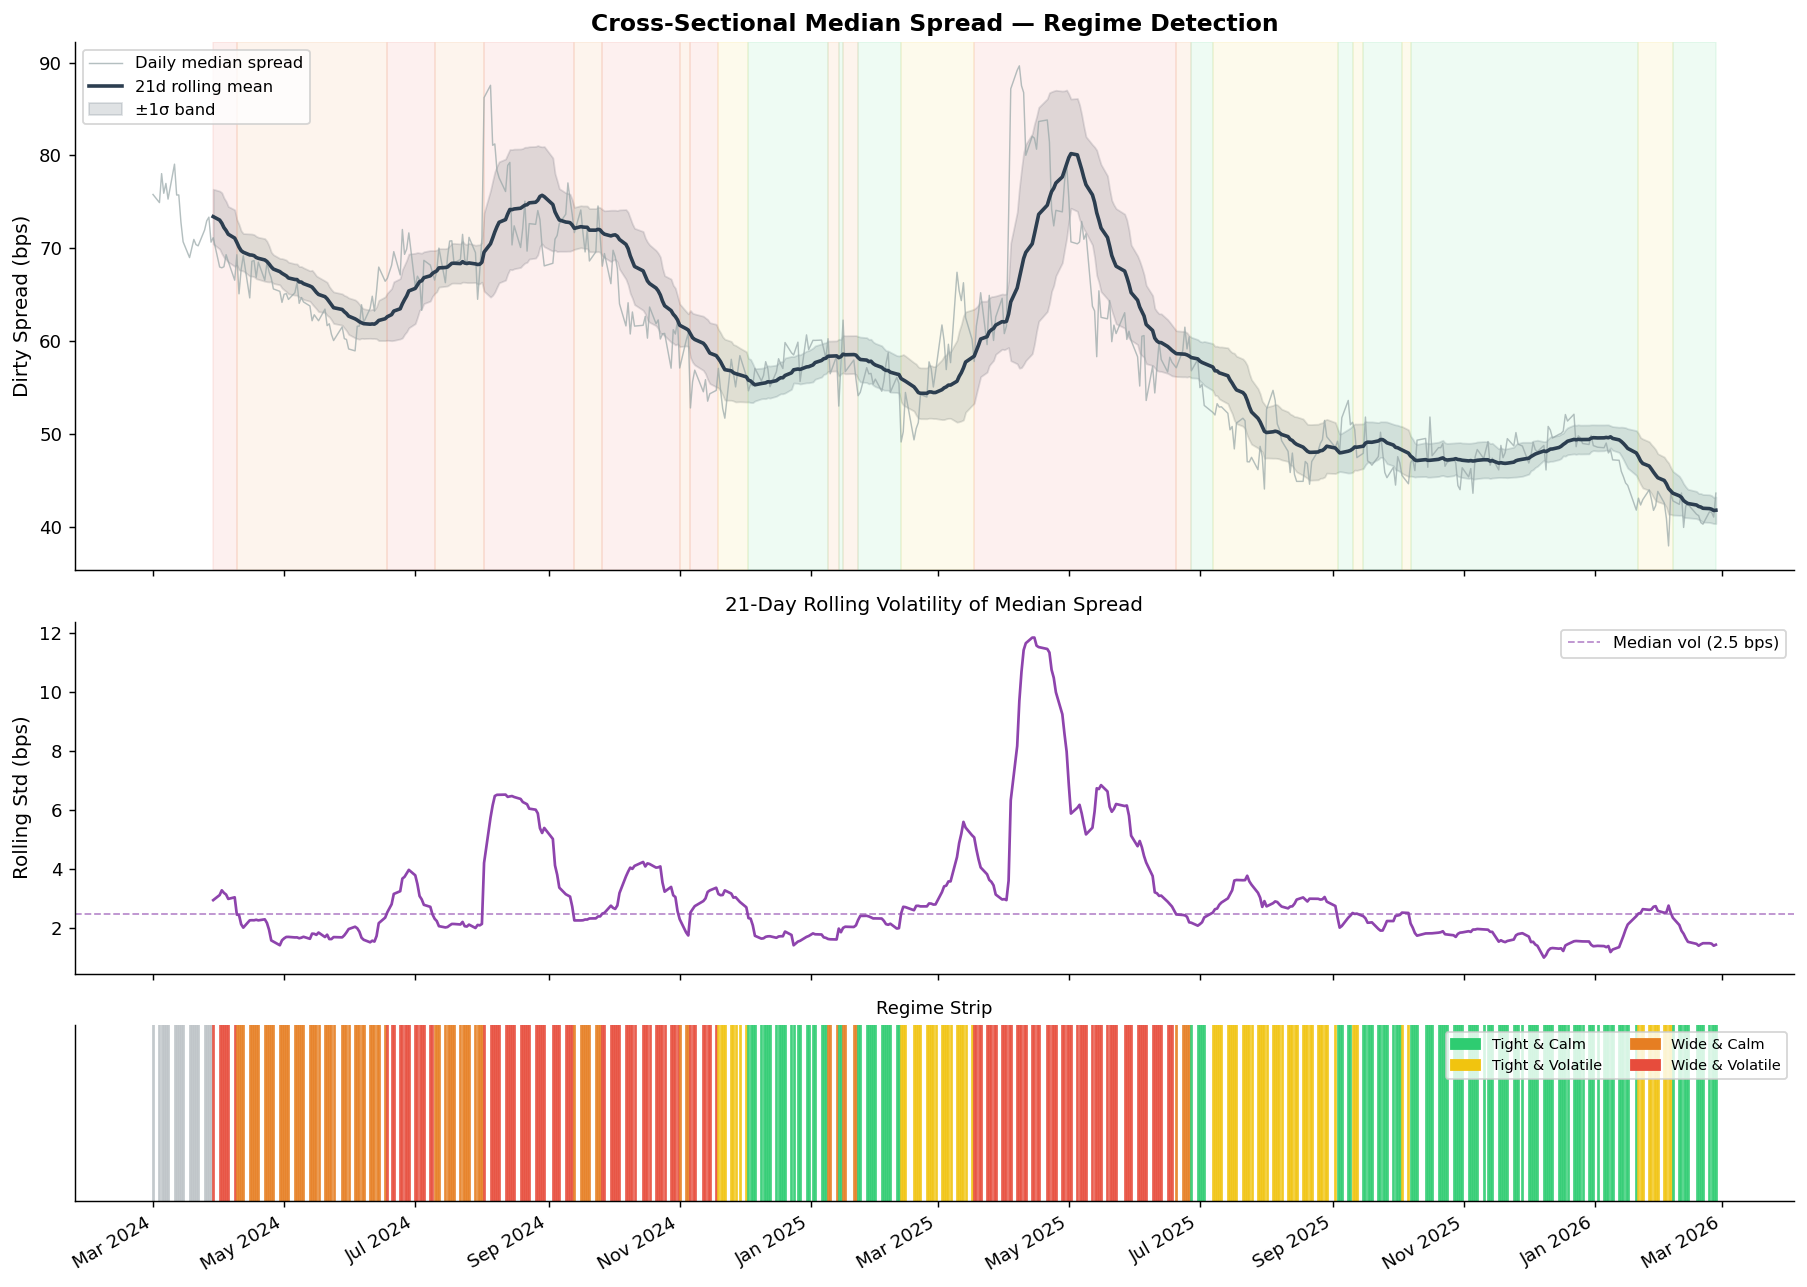


Regime day counts:
Tight & Calm        150
Wide & Volatile     149
Wide & Calm          90
Tight & Volatile     90


In [2]:
# Cross-sectional median spread each day (robust to outliers / missing)
cs_median = spreads.median(axis=1)

WINDOW = 21  # ~1 trading month
roll_mean = cs_median.rolling(WINDOW).mean()
roll_std  = cs_median.rolling(WINDOW).std()

# ── Regime classification ──────────────────────────────────────────────────
# Based on rolling mean vs its own median + rolling vol vs its own median
mean_thresh = roll_mean.median()
vol_thresh  = roll_std.median()

def classify(m, v):
    if pd.isna(m) or pd.isna(v):
        return 'Warm-up'
    if m <= mean_thresh and v <= vol_thresh:
        return 'Tight & Calm'
    if m <= mean_thresh and v > vol_thresh:
        return 'Tight & Volatile'
    if m > mean_thresh and v <= vol_thresh:
        return 'Wide & Calm'
    return 'Wide & Volatile'

regime = pd.Series(
    [classify(m, v) for m, v in zip(roll_mean, roll_std)],
    index=cs_median.index
)

regime_colors = {
    'Tight & Calm':     '#2ecc71',
    'Tight & Volatile': '#f1c40f',
    'Wide & Calm':      '#e67e22',
    'Wide & Volatile':  '#e74c3c',
    'Warm-up':          '#bdc3c7',
}

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 1]})

# Panel 1: spread level + rolling mean + ±1σ band
ax = axes[0]
ax.plot(cs_median.index, cs_median, color='#95a5a6', lw=0.8, alpha=0.7, label='Daily median spread')
ax.plot(roll_mean.index, roll_mean, color='#2c3e50', lw=2, label=f'{WINDOW}d rolling mean')
ax.fill_between(roll_mean.index,
                roll_mean - roll_std,
                roll_mean + roll_std,
                alpha=0.15, color='#2c3e50', label='±1σ band')
ax.set_ylabel('Dirty Spread (bps)', fontsize=11)
ax.set_title('Cross-Sectional Median Spread — Regime Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Shade regime background on panel 1
prev_regime = None
start_date = None
for date, reg in regime.items():
    if reg != prev_regime:
        if prev_regime is not None and prev_regime != 'Warm-up':
            ax.axvspan(start_date, date, alpha=0.08, color=regime_colors[prev_regime])
        start_date = date
        prev_regime = reg
if prev_regime and prev_regime != 'Warm-up':
    ax.axvspan(start_date, cs_median.index[-1], alpha=0.08, color=regime_colors[prev_regime])

# Panel 2: rolling volatility
ax2 = axes[1]
ax2.plot(roll_std.index, roll_std, color='#8e44ad', lw=1.5)
ax2.axhline(vol_thresh, color='#8e44ad', lw=1, ls='--', alpha=0.6, label=f'Median vol ({vol_thresh:.1f} bps)')
ax2.set_ylabel('Rolling Std (bps)', fontsize=11)
ax2.set_title('21-Day Rolling Volatility of Median Spread', fontsize=11)
ax2.legend(fontsize=9)

# Panel 3: regime strip
ax3 = axes[2]
for i, (date, reg) in enumerate(regime.items()):
    ax3.axvline(date, color=regime_colors.get(reg, 'grey'), lw=1.5, alpha=0.9)
ax3.set_yticks([])
ax3.set_title('Regime Strip', fontsize=10)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in regime_colors.items() if k != 'Warm-up']
ax3.legend(handles=legend_patches, loc='upper right', fontsize=8, ncol=2)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

print("\nRegime day counts:")
print(regime[regime != 'Warm-up'].value_counts().to_string())

---
## 2 · Rating Cohort Spread Divergence Over Time

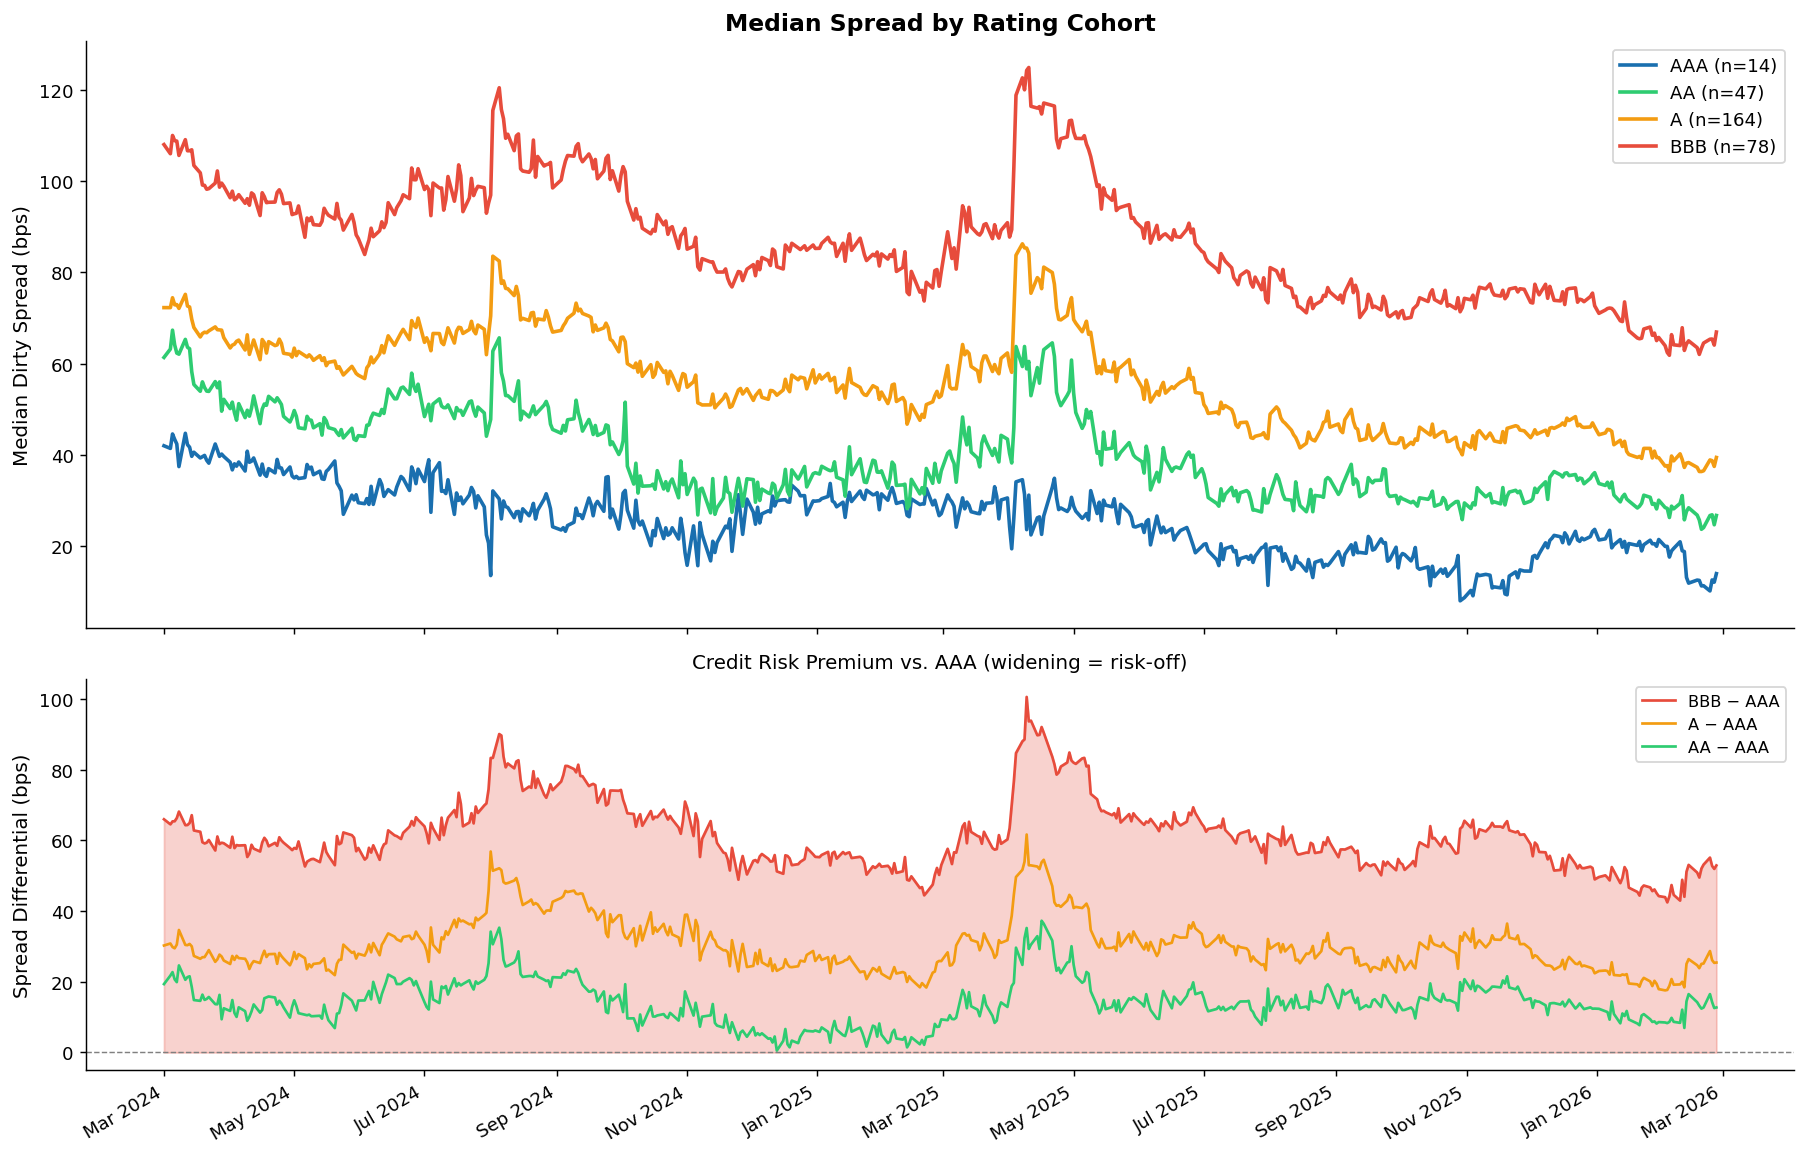


Bond count per rating tier:
Rating_Broad
AAA     14
AA      47
A      164
BBB     78

Mean spread by rating tier (full period):
AAA    25.7
AA     39.8
A      56.1
BBB    87.2


In [3]:
# Collapse to broad rating tier (strip +/- modifiers)
def broad_rating(r):
    for tier in ['AAA', 'AA', 'A', 'BBB']:
        if str(r).startswith(tier):
            return tier
    return 'Other'

meta['Rating_Broad'] = meta['BBG Composite'].apply(broad_rating)

RATING_ORDER  = ['AAA', 'AA', 'A', 'BBB']
RATING_COLORS = {'AAA': '#1a6faf', 'AA': '#2ecc71', 'A': '#f39c12', 'BBB': '#e74c3c'}

# Median spread per rating tier per day
rating_ts = {}
for tier in RATING_ORDER:
    cusips = meta[meta['Rating_Broad'] == tier].index.intersection(spreads.columns)
    rating_ts[tier] = spreads[cusips].median(axis=1)

rating_df = pd.DataFrame(rating_ts)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2]})

# Panel 1: absolute spread levels
ax = axes[0]
for tier in RATING_ORDER:
    n = (meta['Rating_Broad'] == tier).sum()
    ax.plot(rating_df.index, rating_df[tier],
            label=f'{tier} (n={n})', color=RATING_COLORS[tier], lw=2)
ax.set_ylabel('Median Dirty Spread (bps)', fontsize=11)
ax.set_title('Median Spread by Rating Cohort', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Panel 2: spread of spreads (BBB minus AAA = excess credit premium)
ax2 = axes[1]
bbb_aaa = rating_df['BBB'] - rating_df['AAA']
a_aaa   = rating_df['A']   - rating_df['AAA']
aa_aaa  = rating_df['AA']  - rating_df['AAA']
ax2.fill_between(bbb_aaa.index, bbb_aaa, alpha=0.25, color='#e74c3c')
ax2.plot(bbb_aaa.index, bbb_aaa, color='#e74c3c', lw=1.5, label='BBB − AAA')
ax2.plot(a_aaa.index,   a_aaa,   color='#f39c12', lw=1.5, label='A − AAA')
ax2.plot(aa_aaa.index,  aa_aaa,  color='#2ecc71', lw=1.5, label='AA − AAA')
ax2.axhline(0, color='grey', lw=0.8, ls='--')
ax2.set_ylabel('Spread Differential (bps)', fontsize=11)
ax2.set_title('Credit Risk Premium vs. AAA (widening = risk-off)', fontsize=11)
ax2.legend(fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

print("\nBond count per rating tier:")
print(meta['Rating_Broad'].value_counts().reindex(RATING_ORDER).to_string())

print("\nMean spread by rating tier (full period):")
print(rating_df.mean().reindex(RATING_ORDER).round(1).to_string())

---
## 3 · Duration-Adjusted Spread by Sector (BICS Level 1)

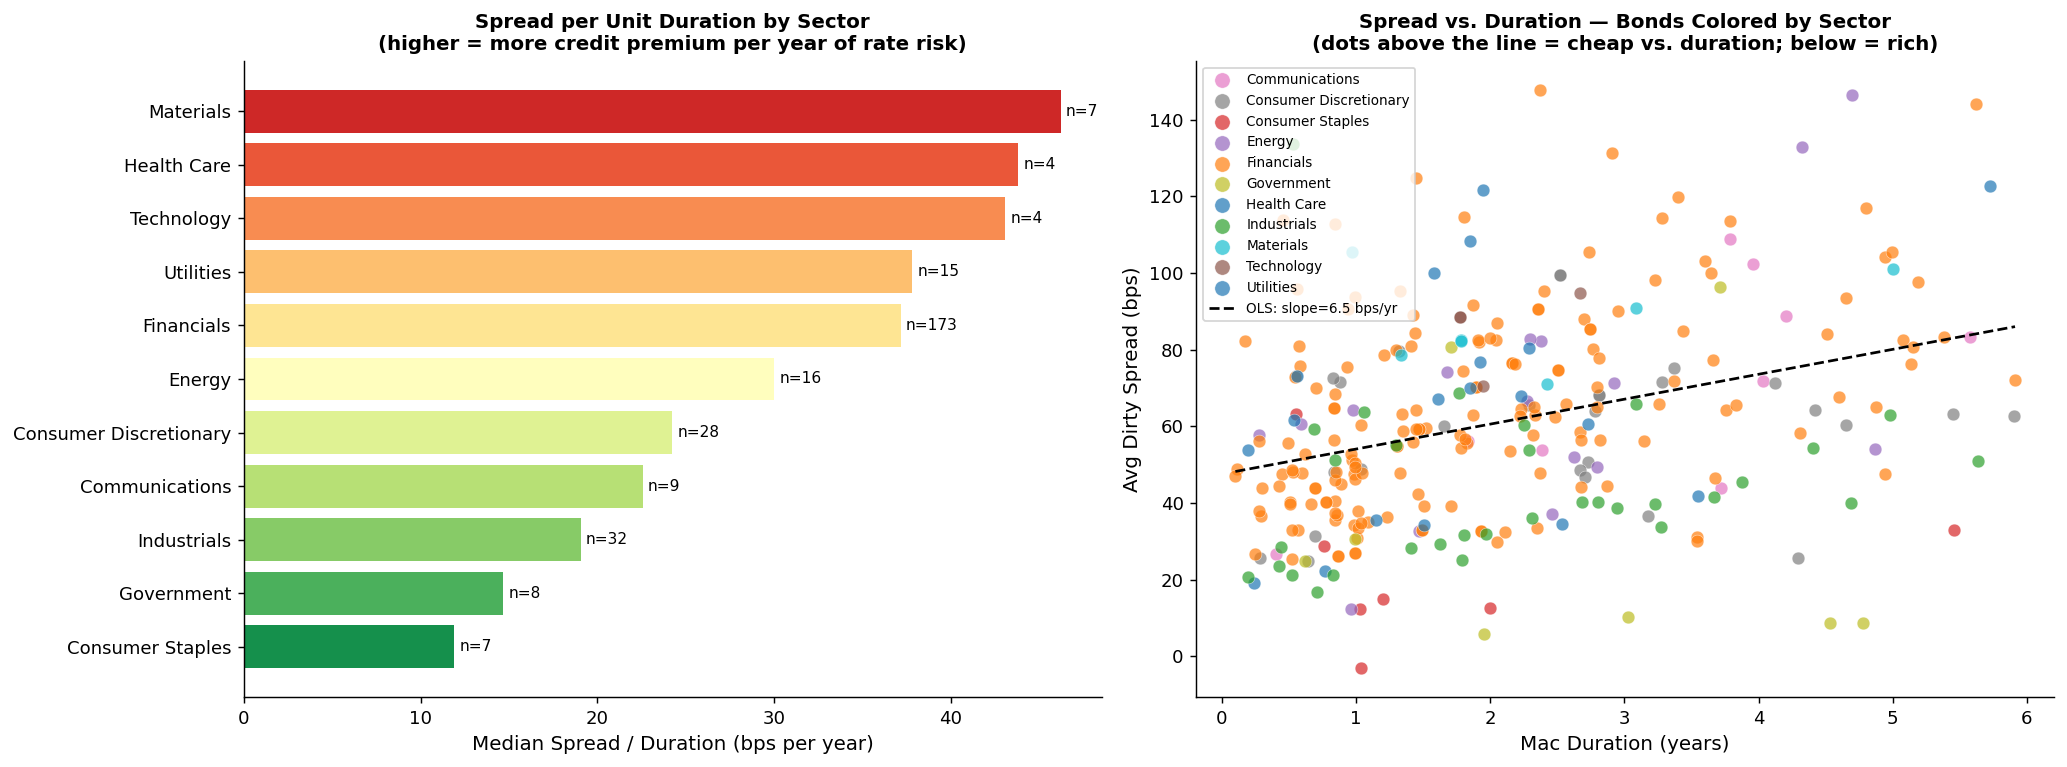


Sector summary:
                        N bonds  Median Spread (bps)  Median Duration (yrs)  Spread/Duration
sector                                                                                      
Consumer Staples              7                14.83                   1.04            11.90
Government                    8                17.48                   2.49            14.67
Industrials                  32                40.07                   1.89            19.06
Communications                9                71.78                   3.79            22.56
Consumer Discretionary       28                63.64                   2.69            24.23
Energy                       16                62.32                   2.34            29.98
Financials                  173                59.52                   1.52            37.15
Utilities                    15                68.02                   1.85            37.79
Technology                    4                88.65 

In [4]:
# For each bond: time-averaged spread, then divide by Mac Duration
avg_spread = spreads.mean()                     # Series: CUSIP → mean spread
dur        = meta['Mac Dur (Ask)']              # Series: CUSIP → duration
sector     = meta['BICS_LEVEL_1_SECTOR_NAME']   # Series: CUSIP → sector

bond_stats = pd.DataFrame({
    'avg_spread':    avg_spread,
    'duration':      dur,
    'sector':        sector,
    'rating':        meta['Rating_Broad'],
}).dropna()

bond_stats['spread_per_dur'] = bond_stats['avg_spread'] / bond_stats['duration']

# Sector-level aggregation
sector_agg = (
    bond_stats.groupby('sector')
    .agg(
        n            = ('avg_spread', 'count'),
        med_spread   = ('avg_spread', 'median'),
        med_dur      = ('duration',   'median'),
        med_spd_dur  = ('spread_per_dur', 'median'),
    )
    .sort_values('med_spd_dur', ascending=True)
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('RdYlGn_r', len(sector_agg))

# Left: spread per unit duration (the key metric)
ax = axes[0]
bars = ax.barh(sector_agg.index, sector_agg['med_spd_dur'], color=colors)
ax.set_xlabel('Median Spread / Duration (bps per year)', fontsize=11)
ax.set_title('Spread per Unit Duration by Sector\n(higher = more credit premium per year of rate risk)',
             fontsize=11, fontweight='bold')
for bar, (_, row) in zip(bars, sector_agg.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n'])}", va='center', fontsize=8.5)

# Right: scatter — duration vs spread, colored by sector
ax2 = axes[1]
sectors_uniq = bond_stats['sector'].unique()
cmap = dict(zip(sectors_uniq, sns.color_palette('tab10', len(sectors_uniq))))
for sec, grp in bond_stats.groupby('sector'):
    ax2.scatter(grp['duration'], grp['avg_spread'],
                color=cmap[sec], label=sec, alpha=0.7, edgecolors='white', lw=0.3, s=50)

# OLS regression line
x = bond_stats['duration']
y = bond_stats['avg_spread']
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 200)
ax2.plot(xline, m * xline + b, color='black', lw=1.5, ls='--',
         label=f'OLS: slope={m:.1f} bps/yr')
ax2.set_xlabel('Mac Duration (years)', fontsize=11)
ax2.set_ylabel('Avg Dirty Spread (bps)', fontsize=11)
ax2.set_title('Spread vs. Duration — Bonds Colored by Sector\n(dots above the line = cheap vs. duration; below = rich)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=7.5, markerscale=1.2, loc='upper left')

plt.tight_layout()
plt.show()

print("\nSector summary:")
print(sector_agg.rename(columns={
    'n': 'N bonds',
    'med_spread': 'Median Spread (bps)',
    'med_dur': 'Median Duration (yrs)',
    'med_spd_dur': 'Spread/Duration'
}).round(2).to_string())

---
## 4 · Spread Correlation Clustering

We compute **daily spread *changes*** (first differences), then the 303×303 pairwise correlation matrix.  
Hierarchical clustering is applied and bonds are sorted by cluster — so the heatmap block structure directly shows which bonds move together.  
The dendrogram annotation labels each cluster by its dominant sector and rating, revealing *what* is driving co-movement.

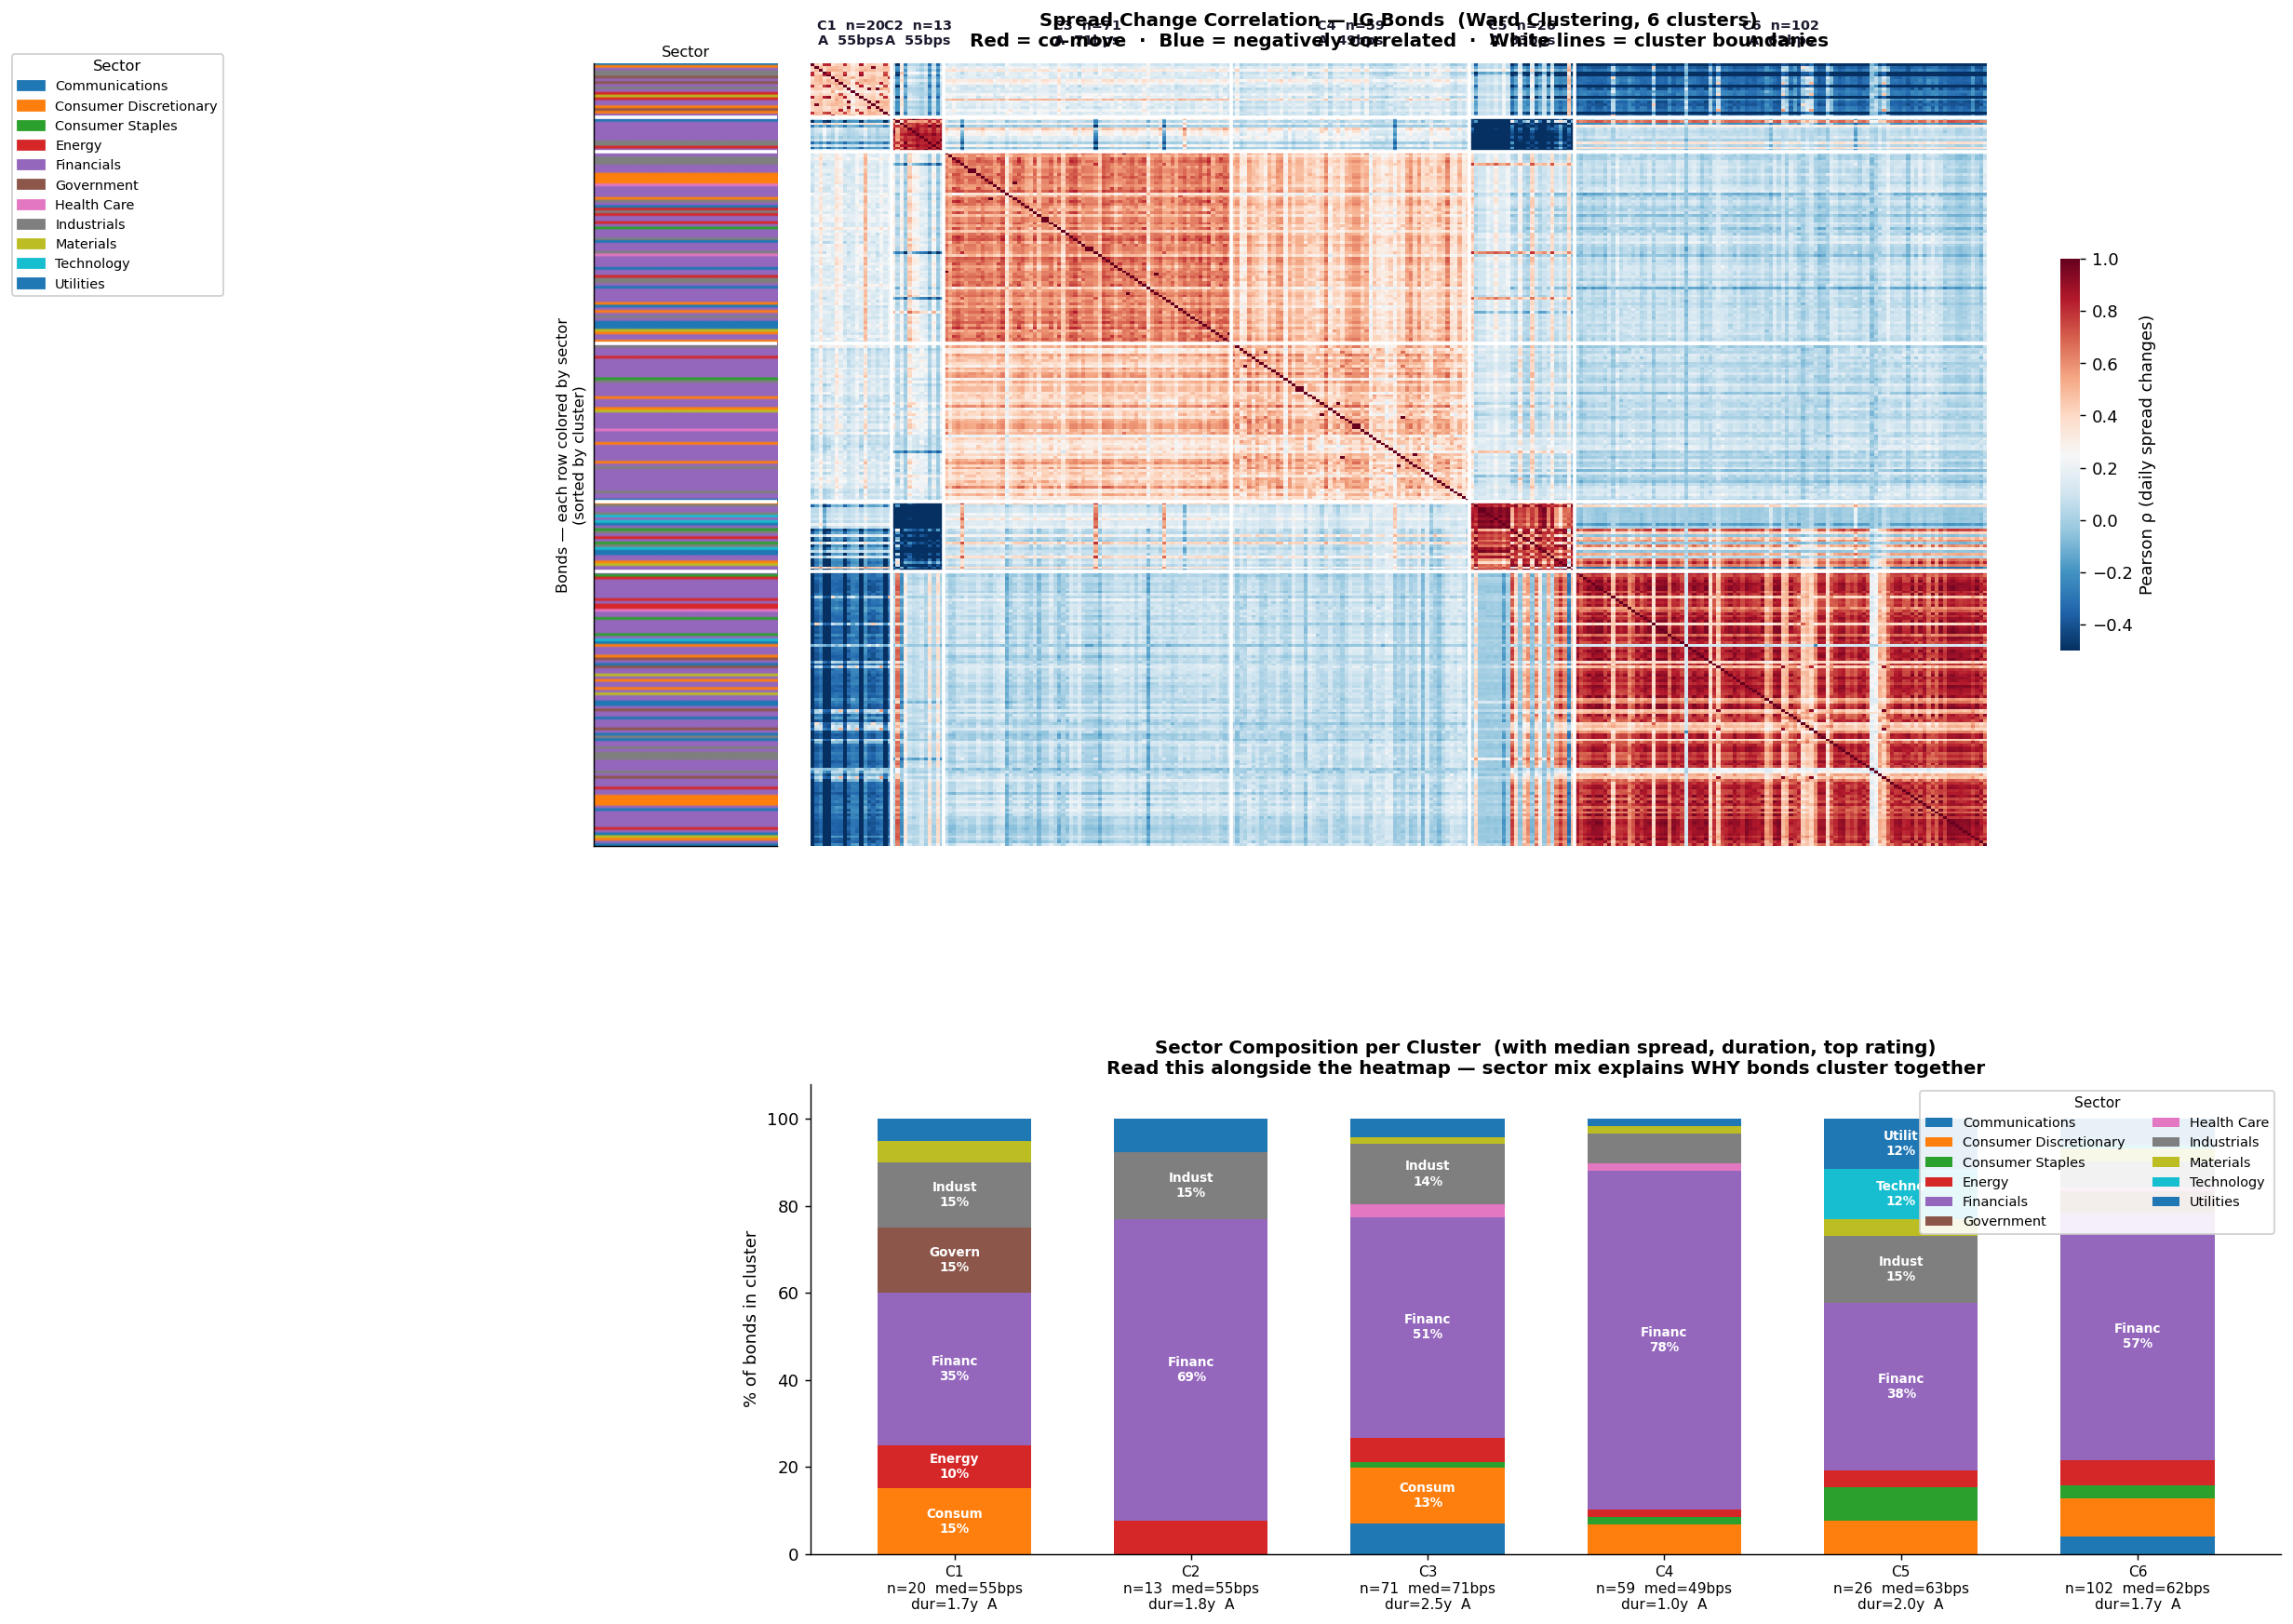


Cluster profiles:
           N  Med_Spread  Med_Dur Top_Rating
cluster                                     
1         20        54.7      1.7          A
2         13        54.8      1.8          A
3         71        71.2      2.5          A
4         59        48.6      1.0          A
5         26        63.0      2.0          A
6        102        62.1      1.7          A

Sector breakdown per cluster (bond counts):
BICS_LEVEL_1_SECTOR_NAME  Communications  Consumer Discretionary  Consumer Staples  Energy  Financials  Government  Health Care  Industrials  Materials  Technology  Utilities
cluster                                                                                                                                                                       
1                                      0                       3                 0       2           7           3            0            3          1           0          1
2                                      0           

In [5]:

# ── Spread changes + correlation ────────────────────────────────────────────
delta = spreads.diff().dropna(how='all')

keep  = delta.columns[delta.isnull().mean() < 0.20]
delta = delta[keep].fillna(0)
corr  = delta.corr()

# ── Hierarchical clustering ─────────────────────────────────────────────────
distance = squareform(np.clip(1 - corr, 0, None))
Z = linkage(distance, method='ward')

N_CLUSTERS = 6
cluster_labels = fcluster(Z, N_CLUSTERS, criterion='maxclust')
order = np.argsort(cluster_labels)

corr_ordered   = corr.iloc[order, order]
cusips_ordered = corr.columns[order]

# ── Cluster metadata ────────────────────────────────────────────────────────
cluster_series = pd.Series(cluster_labels, index=corr.columns)
cluster_meta   = meta.loc[meta.index.intersection(corr.columns)].copy()
cluster_meta['cluster'] = cluster_series
cluster_meta   = cluster_meta.join(avg_spread.rename('avg_spread'), how='left')

cluster_profile = (
    cluster_meta.groupby('cluster')
    .agg(
        N          = ('BICS_LEVEL_1_SECTOR_NAME', 'count'),
        Med_Spread = ('avg_spread',    'median'),
        Med_Dur    = ('Mac Dur (Ask)', 'median'),
        Top_Rating = ('Rating_Broad',  lambda x: x.value_counts().index[0]),
    )
)

# ── Sector color map ─────────────────────────────────────────────────────────
all_sectors   = sorted(cluster_meta['BICS_LEVEL_1_SECTOR_NAME'].dropna().unique())
sector_colors = dict(zip(all_sectors, sns.color_palette('tab10', len(all_sectors))))

# ── Figure layout: 2 rows × 2 cols ──────────────────────────────────────────
#   Row 0: [sector strip | heatmap]
#   Row 1: [blank        | stacked sector-composition bar]
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 8],
    height_ratios=[5, 3],
    hspace=0.38, wspace=0.04
)

ax_strip = fig.add_subplot(gs[0, 0])   # sector strip
ax_heat  = fig.add_subplot(gs[0, 1])   # heatmap
ax_bar   = fig.add_subplot(gs[1, 1])   # composition bars

# ── 1. Correlation heatmap ───────────────────────────────────────────────────
sns.heatmap(
    corr_ordered,
    ax=ax_heat,
    cmap='RdBu_r',
    vmin=-0.5, vmax=1,
    xticklabels=False, yticklabels=False,
    cbar_kws={'label': 'Pearson ρ (daily spread changes)', 'shrink': 0.5},
)
ax_heat.set_title(
    'Spread Change Correlation — IG Bonds  (Ward Clustering, 6 clusters)\n'
    'Red = co-move  ·  Blue = negatively correlated  ·  White lines = cluster boundaries',
    fontsize=11, fontweight='bold', pad=10
)

# Cluster boundary lines + top labels
boundaries = np.where(np.diff(cluster_labels[order]))[0] + 1
for b in boundaries:
    ax_heat.axhline(b, color='white', lw=2)
    ax_heat.axvline(b, color='white', lw=2)

prev_cl, seg_start = cluster_labels[order][0], 0
for idx in range(len(order) + 1):
    cl = cluster_labels[order][idx] if idx < len(order) else -1
    if cl != prev_cl:
        mid = (seg_start + idx) / 2
        row = cluster_profile.loc[prev_cl]
        ax_heat.text(
            mid, -6,
            f'C{prev_cl}  n={int(row["N"])}\n{row["Top_Rating"]}  {row["Med_Spread"]:.0f}bps',
            ha='center', va='bottom', fontsize=8, color='#1a1a2e', fontweight='bold'
        )
        seg_start, prev_cl = idx, cl

# ── 2. Sector color strip (each row = one bond, colored by sector) ───────────
sec_seq   = cluster_meta.loc[cusips_ordered, 'BICS_LEVEL_1_SECTOR_NAME'].values
strip_rgb = np.array([[sector_colors.get(s, (0.7, 0.7, 0.7)) for s in sec_seq]])
ax_strip.imshow(strip_rgb.reshape(-1, 1, 3), aspect='auto', origin='upper')

for b in boundaries:
    ax_strip.axhline(b - 0.5, color='white', lw=2)

ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_ylabel('Bonds — each row colored by sector\n(sorted by cluster)', fontsize=9)
ax_strip.set_title('Sector', fontsize=9, pad=4)

# Sector legend beside strip
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in sorted(sector_colors.items())]
ax_strip.legend(
    handles=legend_patches,
    loc='upper left', bbox_to_anchor=(-3.2, 1.02),
    fontsize=8, title='Sector', title_fontsize=9,
    framealpha=0.9, ncol=1
)

# ── 3. Stacked bar: sector composition % per cluster ────────────────────────
comp = (
    cluster_meta.groupby(['cluster', 'BICS_LEVEL_1_SECTOR_NAME'])
    .size()
    .unstack(fill_value=0)
)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

bottom   = np.zeros(N_CLUSTERS)
x_labels = [
    f'C{c}\nn={int(cluster_profile.loc[c,"N"])}  '
    f'med={cluster_profile.loc[c,"Med_Spread"]:.0f}bps\n'
    f'dur={cluster_profile.loc[c,"Med_Dur"]:.1f}y  {cluster_profile.loc[c,"Top_Rating"]}'
    for c in comp_pct.index
]

for sec in comp_pct.columns:
    vals = comp_pct[sec].values
    ax_bar.bar(range(N_CLUSTERS), vals, bottom=bottom,
               color=sector_colors.get(sec, 'grey'), label=sec, width=0.65)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 9:
            ax_bar.text(i, b + v / 2, f'{sec[:6]}\n{v:.0f}%',
                        ha='center', va='center', fontsize=7.5,
                        color='white', fontweight='bold')
    bottom += vals

ax_bar.set_xticks(range(N_CLUSTERS))
ax_bar.set_xticklabels(x_labels, fontsize=8.5)
ax_bar.set_ylabel('% of bonds in cluster', fontsize=10)
ax_bar.set_ylim(0, 108)
ax_bar.set_title(
    'Sector Composition per Cluster  (with median spread, duration, top rating)\n'
    'Read this alongside the heatmap — sector mix explains WHY bonds cluster together',
    fontsize=11, fontweight='bold'
)
ax_bar.legend(
    loc='upper right', fontsize=8, title='Sector', title_fontsize=8.5,
    ncol=2, framealpha=0.9
)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

plt.show()

print("\nCluster profiles:")
print(cluster_profile.round(1).to_string())
print("\nSector breakdown per cluster (bond counts):")
print(comp.to_string())


---
## 5 · Spread Distribution by Sector (BICS Level 1)

Dropping 691 observations with Spread < 0 (0.5% of data)


/var/folders/zg/9jdfnwbd0v56xz8n032gjqtc0000gn/T/ipykernel_79535/2738084252.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


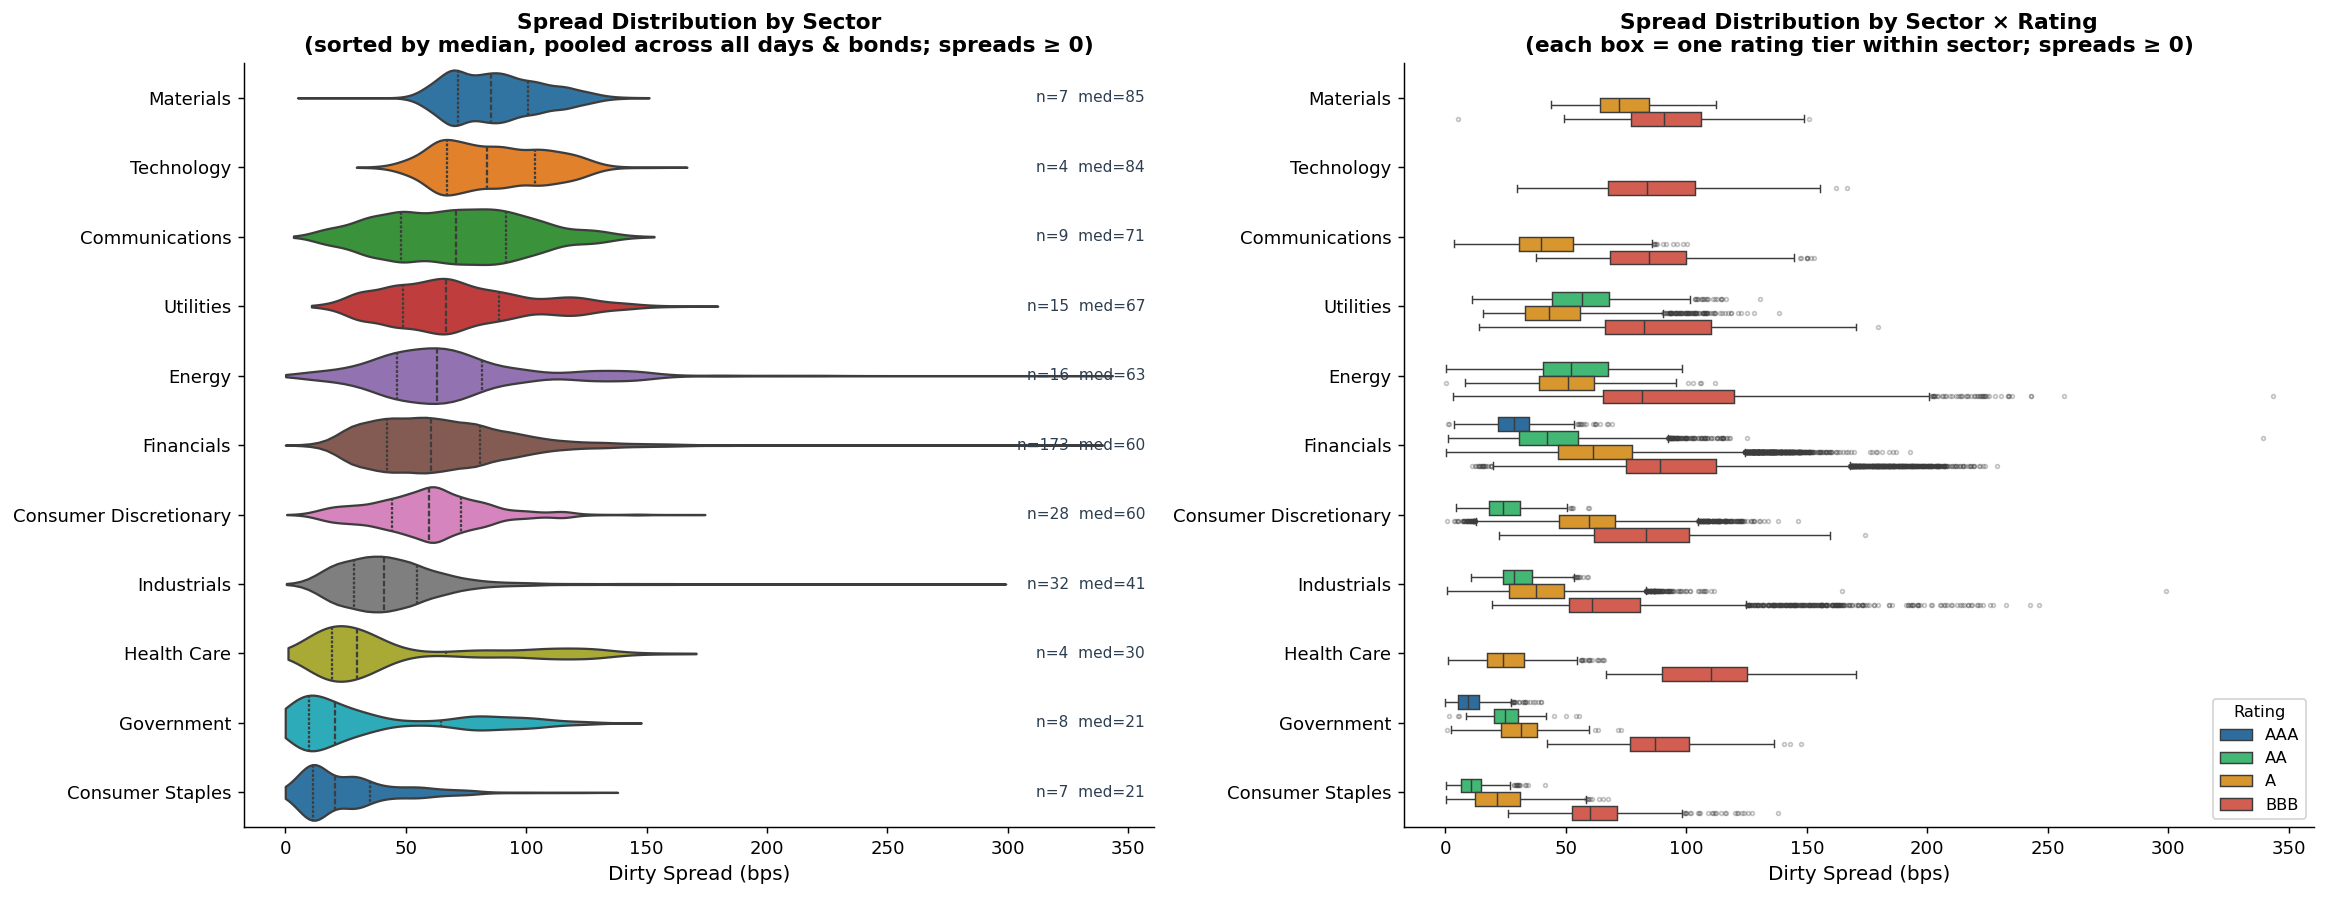


Median spread and spread IQR by sector:
                          Median   Q25    Q75   IQR
BICS_LEVEL_1_SECTOR_NAME                           
Materials                   85.5  71.6  101.0  29.4
Technology                  83.7  67.4  103.5  36.2
Communications              70.8  47.9   91.6  43.7
Utilities                   66.9  48.8   88.6  39.8
Energy                      63.0  46.5   81.5  35.0
Financials                  60.4  42.4   81.0  38.7
Consumer Discretionary      59.6  44.5   72.8  28.3
Industrials                 41.0  28.7   54.7  26.0
Health Care                 30.0  19.3   66.6  47.3
Government                  20.8   9.9   64.8  54.9
Consumer Staples            20.5  11.4   35.3  23.9


In [6]:

# Pool all daily spread observations per sector → long format
spread_long = spreads.stack().reset_index()
spread_long.columns = ['Date', 'CUSIP', 'Spread']
spread_long = spread_long.merge(meta[['BICS_LEVEL_1_SECTOR_NAME', 'Rating_Broad']],
                                left_on='CUSIP', right_index=True, how='left')
spread_long = spread_long.dropna(subset=['Spread', 'BICS_LEVEL_1_SECTOR_NAME'])

# ── Drop negative spreads (data artifacts / settlement noise) ────────────────
n_neg = (spread_long['Spread'] < 0).sum()
print(f"Dropping {n_neg} observations with Spread < 0 ({n_neg/len(spread_long)*100:.1f}% of data)")
spread_long = spread_long[spread_long['Spread'] >= 0]

# Order sectors by median spread descending
sector_order = (
    spread_long.groupby('BICS_LEVEL_1_SECTOR_NAME')['Spread']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

n_sectors = len(sector_order)
palette   = sns.color_palette('tab10', n_sectors)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: violin plots ─────────────────────────────────────────────────────
ax = axes[0]
sns.violinplot(
    data=spread_long,
    x='Spread',
    y='BICS_LEVEL_1_SECTOR_NAME',
    order=sector_order,
    palette=palette,
    inner='quartile',
    cut=0,
    ax=ax,
)
ax.set_xlabel('Dirty Spread (bps)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Spread Distribution by Sector\n(sorted by median, pooled across all days & bonds; spreads ≥ 0)',
             fontsize=12, fontweight='bold')
# Annotate with bond count and median
for i, sec in enumerate(sector_order):
    sub = spread_long[spread_long['BICS_LEVEL_1_SECTOR_NAME'] == sec]
    n_bonds = sub['CUSIP'].nunique()
    med_val = sub['Spread'].median()
    ax.text(ax.get_xlim()[1] * 0.99, i,
            f'n={n_bonds}  med={med_val:.0f}',
            va='center', ha='right', fontsize=8.5, color='#2c3e50')

# ── Right: box plots split by rating within sector ─────────────────────────
ax2 = axes[1]
rating_palette = {'AAA': '#1a6faf', 'AA': '#2ecc71', 'A': '#f39c12', 'BBB': '#e74c3c'}
sns.boxplot(
    data=spread_long[spread_long['Rating_Broad'].isin(RATING_ORDER)],
    x='Spread',
    y='BICS_LEVEL_1_SECTOR_NAME',
    order=sector_order,
    hue='Rating_Broad',
    hue_order=RATING_ORDER,
    palette=rating_palette,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    linewidth=0.8,
    ax=ax2,
)
ax2.set_xlabel('Dirty Spread (bps)', fontsize=11)
ax2.set_ylabel('')
ax2.set_title('Spread Distribution by Sector × Rating\n(each box = one rating tier within sector; spreads ≥ 0)',
              fontsize=12, fontweight='bold')
ax2.legend(title='Rating', fontsize=9, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print("\nMedian spread and spread IQR by sector:")
print(
    spread_long.groupby('BICS_LEVEL_1_SECTOR_NAME')['Spread']
    .agg(Median='median', Q25=lambda x: x.quantile(0.25), Q75=lambda x: x.quantile(0.75))
    .assign(IQR=lambda d: d['Q75'] - d['Q25'])
    .round(1)
    .sort_values('Median', ascending=False)
    .to_string()
)
